# Project KALM: Kalman-based Adaptive Linear Modeling

**Student:**  
Dominik Bernhard 

**Modul name:**  
dcom (Digital Communication)

**Lecturer:**  
Prof. Dr. Mathieu Coustans

**Semester:**  
FS2025 - 07.2025

**University:**  
University of Applied Sciences Brugg - Windisch  

---

This notebook leverages standard `numpy` and `matplotlib` Python libraries.


## My Real World Example: Combining Sensor Data to estimate Ball Throw Distance

**Situation:**  
There is a school contest where kids have to throw a ball as far as possible. There are oldschool methodes like using a measuring tape, however because of the amount of kids the organizer decided to use digital measurements in combination with a kalman filter to estimate the distance.
There are two different types of sensor data available:

- **Camera:**
    - A camera is placed at the side and records the throw.
    - It has high resolution, but the drawback is, that it only operates at 30 FPS (1 picture every 33 ms)
    - Using image processing the absolute horizontal distance is determined every 33 ms
    - Tests showed that the absolute accuracy of the measurement is +/- 40 cm (Gaussian Distributed)

- **Interial measurement unit (IMU) inside the ball:**
    - Inside the ball there is a IMU sensor (gyroscope & accelerometer).
    - During the flight, this sensor continuously measures acceleration and rotation.
    - By integrating the sensor data, it is possible to estimate the distance the ball has traveled over time.
    - The IMU sensor is incredibly fast and spits out measuring data every 1ms
    - The speed is calculated internally and tests showed that it's accuracy is +/- 5% (Gaussian Distributed)
    - This method gives high-resolution data, but errors accumulate over time, leading to drift and increasing inaccuracy.
    - On hot days there is a positive 2% uncompensated offset

**Problem:**  
Both measurement systems are imperfect and have their typical weaknesses:

- The **camera** provides absolute measurement values, which can be imprecise due to limited visibility, distortions, or environmental conditions.
- The **IMU in the ball** provides frequent data, but small errors add up, causing the estimated distance to drift away from the true value over time.

**Solution with Kalman Filter:**  
A Kalman filter can intelligently combine both sources of data and exploit the strengths of each system:

- The IMU data is used continuously to predict the position (*prediction step*).
- The camera measurement is used to correct the estimate (*correction step*) when it becomes available.
- The Kalman filter calculates the optimal estimate of the ball’s distance at each point in time, giving more weight to the more reliable measurement.

**Application:**  
By combining onboard sensor data and camera measurements, the true throw distance of the ball can be determined much more accurately than with either measurement alone.


## Generating the data of the actual ball throw
This generated data corresponds to the ball thrown in an ideal world. The generated data which is labeled **true_xxx** means, that there is absolute no Error/Noise ore other factors present. This data is used as the reference. 
In order to simulate data of a throw we need to set some parameters, in this case the duration of the throw. 

Furthermore the sample frequency for the camera and the IMU need to be set. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- Simulation Parameter ---
T_total = 8.127   # Gesamtdauer Wurf in Sekunden
dt_imu = 0.001  # IMU Abtastrate [s] (1 ms Abtastrate)
dt_cam = 0.033    # Kamera Abtastrate [s] (30 FPS) --> alle 33ms kommt 1 Bild

N_imu = int(T_total / dt_imu) + 1      # Anzahl IMU Samples
N_cam = int(T_total / dt_cam) + 1      # Anzahl Kamera Frames

# --- "Echter" Ballflug (simuliert als gleichmäßige Geschwindigkeit) ---
true_velocity = 14.0  # [m/s] Horizontale Geschwindigkeit (z.B. Ballwurf)
true_positions = np.arange(0, N_imu) * dt_imu * true_velocity



## Generate IMU data
In a real world application an IMU is not directly capable to give the user a **velocity** value. An IMU is only able to measure its acceleration. To keep this project clear and simple and to focus on the main task (the kalman filter) will be accepted that the IMU directly measures the velocity. 

The measured velocity of the IMU is erroneous. Responsible for the deviations from the actual value in this example are:
- Gaussian distributed measurement error (Noise), (The measurement error should be read out of the IMU datasheet)
- Uncompensated temperature offset (systematic error, which can not be corrected in this case) the offset will either always be positive or negative

In [2]:
# --- IMU-Data Simulation: ---
imu_noise_percent = 0.05  # 5% Messfehler (relativ zum true_velocity)
imu_velocity_offset_causedByTemperature = true_velocity * (1+0.02) # +2% Temperatur offset
imu_measured_velocity = imu_velocity_offset_causedByTemperature * (1 + np.random.randn(N_imu) * imu_noise_percent) #mean = 0, variance = 1
imu_measured_positions = np.cumsum(imu_measured_velocity * dt_imu) # Alle einzelnen Werte aufsummieren und speichern



## Generate Camera data

The camera is mounted perpendicular to the direction in which the ball is thrown. The ball throw is recorded with a framerate of 30 frames per second. Each image is analyzed by an image processing algorithm. The software output is the absolute distance the ball current has from its drop point. 

In contrast to the IMU, errors do not add up from one measurement to the next when working with the camera.

Tests showed a deviation from the actual distance from +/- 0.4m when using the camera setup. This corresponds to a standard deviation interval (±1 σ) - i.e. around 68 % of all measured values are within this range.

In [3]:
# --- Kamera-Data Simulation: ---
cam_noise_abs = 0.4  # Messfehler der Kamera in m absolut
cam_indices = np.arange(0, N_imu, int(dt_cam / dt_imu))
cam_true_positions = true_positions[cam_indices]
cam_measured_positions = cam_true_positions + np.random.randn(len(cam_true_positions)) * cam_noise_abs

# --- "Nur Kamera"-Schätzung (linear interpoliert zwischen den Kamera-Frames) ---
camera_only_estimate = np.interp(np.arange(N_imu), cam_indices, cam_measured_positions)


## Setup the Kalman Filter

The purpose of the Kalman filter is to combine the measured values of the IMU with the measured values of the camera. The aim is to combine two measured values that are subject to measurement errors in order to obtain an estimate with a smaller error.

To understand the function of the Kalman filter, its parameters need to be understood:

---

**State Vector `x`**

A 2×1 vector that contains position and velocity:

$$
x = 
\begin{pmatrix}
  x[0] \\\\
  x[1]
\end{pmatrix}
$$

- `x[0]`: Position  
- `x[1]`: Velocity  

The state vector stores the current best estimate. If another sample value is received (e.g. from the IMU sensor), the state vector is adjusted. 

---


**Error Covariance Matrix `P`**

A 2×2 matrix representing the uncertainty in position and velocity estimates:

$$
P = 
\begin{pmatrix}
  P_{00} & P_{01} \\\\
  P_{10} & P_{11}
\end{pmatrix}
$$

- `P₀₀`: Variance of the **position** estimate  
- `P₁₁`: Variance of the **velocity** estimate  
- `P₀₁` & `P₁₀`: Covariance between position and velocity  
  (indicates how uncertainties in the two estimates are correlated)

The Error Covariance Matrix is adjusted with each new sample value (e.g. from the IMU sensor) as part of the prediction step. When a new camera measurement is present, a correction step is done, which also leads to an adjustment of the Error Covariance Matrix.

---

**State Transition Matrix `A`**

Models how the system evolves over time using IMU time step `dt_imu`:

$$
A = 
\begin{pmatrix}
  1 & dt\_imu \\\\
  0 & 1
\end{pmatrix}
$$

- `Top line (position)`: Previous position + (velocity × time)
- `Bottom line (velocity)`: Velocity remains unchanged (constant velocity model)

The State Transition Matrix describes how the two state variables (position & velocity) develop in one step. The step size is given by the IMU sample rate `dt_imu`, because this is the sensor with the highest data output.


---

**Process Noise Covariance `Q`**

Diagonal matrix representing uncertainty in the system model:

$$
Q = 
\begin{pmatrix}
  0.001 & 0 \\\\
  0 & 0.05
\end{pmatrix}
$$

This matrix expresses the uncertainty in the prediction model itself (e.g. unmodeled accelerations or sensor drift). Since only the diagonal elements are non-zero, it is assumed that:

- `Q[0,0] = 0.001`: Variance in position estimation (how much we trust the predicted position)
- `Q[1,1] = 0.05`: Variance in velocity estimation

The **off-diagonal elements** are zero:

- `Q[0,1] = Q[1,0] = 0`:  
  This means there is **no assumed correlation** between uncertainty in position and uncertainty in velocity. In other words, the model assumes that noise in one does not directly affect the other.

How to set the values of Q:

- Small `Q` → **High confidence in the model** → Less correction from new measurements  
- Large `Q` → **Low confidence in the model** → Stronger correction from new measurements

A common but non-professional way to find out values for the matrix `Q` is simply to adjust them and see if the kalman filter performs better or worse.


---

**Observation Matrix `H`**

Maps the full state vector to the measured value (only position):

$$
H = 
\begin{pmatrix}
  1 & 0
\end{pmatrix}
$$

The Observation Matrix `H` is used only in the **correction step** of the Kalman Filter.  
Since the camera provides **position measurements only**, the first element is set to `1` (position is observed), and the second element is `0` (velocity is ignored).

---

**Measurement Noise Covariance `R`**

A 1×1 matrix equal to the variance of the camera measurement:

$$
R = 
\begin{pmatrix}
  cam\_noise\_abs^2
\end{pmatrix}
$$

The Measurement Noise Covariance `R` is only used in the **correction step** of the Kalman Filter.

Camera in the correction step:

- As soon as a **camera measurement** is available, it is compared to the **predicted position**.
- To perform this correction, the filter needs a metric for **how much the camera measurement is trusted**.  
  This value is equal to the **variance of the camera noise**
 

---

**Input (Control) Variable `u`**

The velocity measured by the IMU, directly assigned to `x[1]` during prediction:

$$
u = 
\begin{pmatrix}
  u
\end{pmatrix}
$$

The **velocity component** is directly set by the state vector (`x[1]`) to the current IMU measurement.  
Using the **state transition matrix `A`** and **process noise covariance `Q`**, the state and covariance is propagated.

As a result, no separate **control matrix `B`** is needed — the IMU signal is treated as a **quasi-control input**, applied directly without being scaled or transformed via an additional matrix.


---

**Measurement Vector `z`**

A 1×1 vector representing the current camera position:

$$
z = 
\begin{pmatrix}
  z
\end{pmatrix}
$$

`z` is the **actual measurement** from the camera, used in the **correction step** to correct the internal model.  
It provides the reference against which the predicted state is compared.


---

**Innovation Covariance `S`**

Expected variance of the measurement error (innovation):

$$
S = H \cdot P \cdot H^T + R
$$

The Innovation Covariance `S` is used in the **correction step** of the Kalman filter.

How it works:

- **Adaptive weighting:**  
  `S` reflects whether the **model uncertainty** or the **measurement uncertainty** dominates.  
  The filter adjusts automatically:
  - If the measurement is noisy → rely more on the model.
  - If the model is uncertain → rely more on the measurement.

- **Stability:**  
  A correctly calculated `S` prevents **overshooting** in the Kalman Gain and ensures that the filter doesn't overreact to outliers.
  


---

**Kalman Gain `K`**

Weight vector for updating the estimate:

$$
K = P \cdot H^T \cdot S^{-1}
$$

The Kalman Gain `K` is used in the correction step. It determines to what extend the predicted value gets corrected. The Kalman Gain `K`is a measure for how much the new measurement can be trusted compared to the current model.

---

**Innovation (Residual) `y`**

Difference between actual measurement and predicted measurement:

$$
y = z - H \cdot x
$$

The **Innovation** (or **Residual**) `y` represents the difference between what the model **expects** and what is actually **measured**.

More precisely:

- `z` is the **measured value** (in this case: the camera position).
- $H \cdot x$ is the **predicted measurement**, computed from the current state estimate.


So `y` quantifies the discrepancy between prediction and reality — this difference is what the Kalman filter uses to correct and update the internal state.




---

**Camera Indexing**

- `cam_indices`: Array of IMU timesteps when a new camera frame is available  
- `cam_frame_counter`: Tracks the next camera measurement to use


In [4]:
# --- Kalman-Filter Setup ---
x = np.zeros(2)                      # [Position, Geschwindigkeit]
P = np.eye(2) * 1
A = np.array([[1, dt_imu], [0, 1]])  # Systemmatrix
Q = np.diag([0.001, 0.05])
H = np.array([[1, 0]])               # Kamera misst Position
R = np.array([[cam_noise_abs**2]])   # Kamera-Rauschen

kalman_positions = []
kalman_velocities = []
cam_frame_counter = 0



## Estimation & Correction

In this loop, the Kalman filter performs **continuous estimation and correction**:

- At **every IMU timestep**, the system makes a **prediction** of the current state (position & velocity) based on the latest IMU data.

- If a **camera measurement** is available at that timestep, the prediction is **corrected** using this more accurate position information.

This alternating process of **predict → correct → predict → correct** allows the filter to continuously refine its internal state and reduce overall error over time.

At the end, the code compares the final estimation errors from:
- IMU only
- Camera only
- Kalman filter (combined)


In [5]:
for i in range(N_imu):
    # --- Prediction (IMU, jede ms) ---
    u = imu_measured_velocity[i]
    x[1] = u  # Geschwindigkeit "direkt" vom IMU setzen (vereinfachtes Modell)
    x = A @ x
    P = A @ P @ A.T + Q

    # --- Update (Kamera, falls Bild verfügbar) ---
    if i in cam_indices:
        z = np.array([cam_measured_positions[cam_frame_counter]])
        S = H @ P @ H.T + R
        K = P @ H.T @ np.linalg.inv(S)
        y = z - H @ x
        x = x + (K @ y).flatten()
        P = (np.eye(2) - K @ H) @ P
        cam_frame_counter += 1

    kalman_positions.append(x[0])
    kalman_velocities.append(x[1])

t = np.arange(0, N_imu) * dt_imu

# Fehler am Ende (letzter Wert)
err_imu = np.abs(imu_measured_positions[-1] - true_positions[-1])
err_camera = np.abs(camera_only_estimate[-1] - true_positions[-1])
err_kalman = np.abs(kalman_positions[-1] - true_positions[-1])

## Plotting the results

To measure the performance of the Kalman filter, the sensors are first considered individually and then in combination with the Kalman filter.

A good performing Kalman filter should perform better than each sensor individually. 

For each sensor individually (IMU & camera) and the Kalman filter there are two graphs shown:

- Absolute horizontal position of ball during the throw
- Error Convergence 

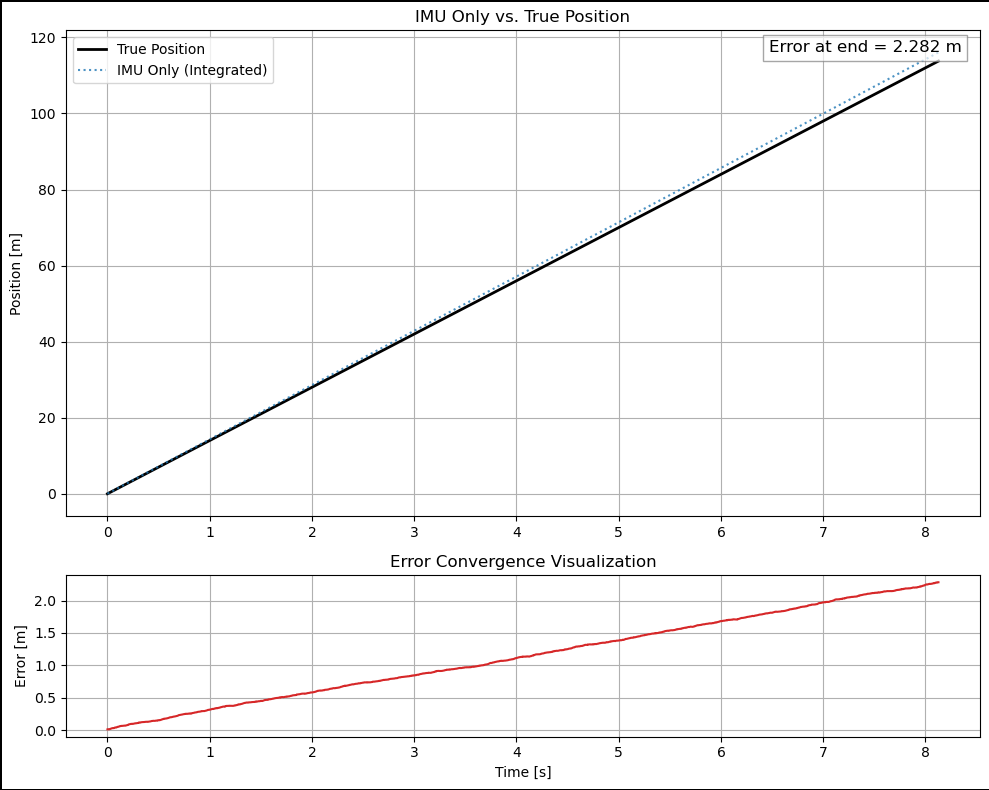

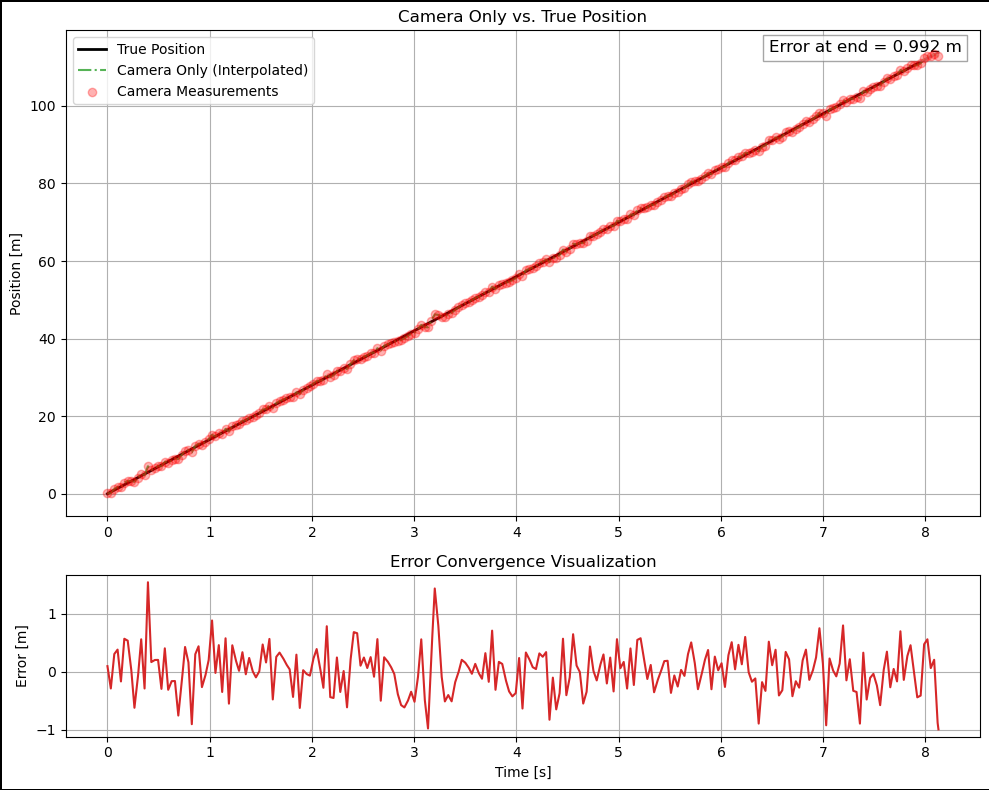

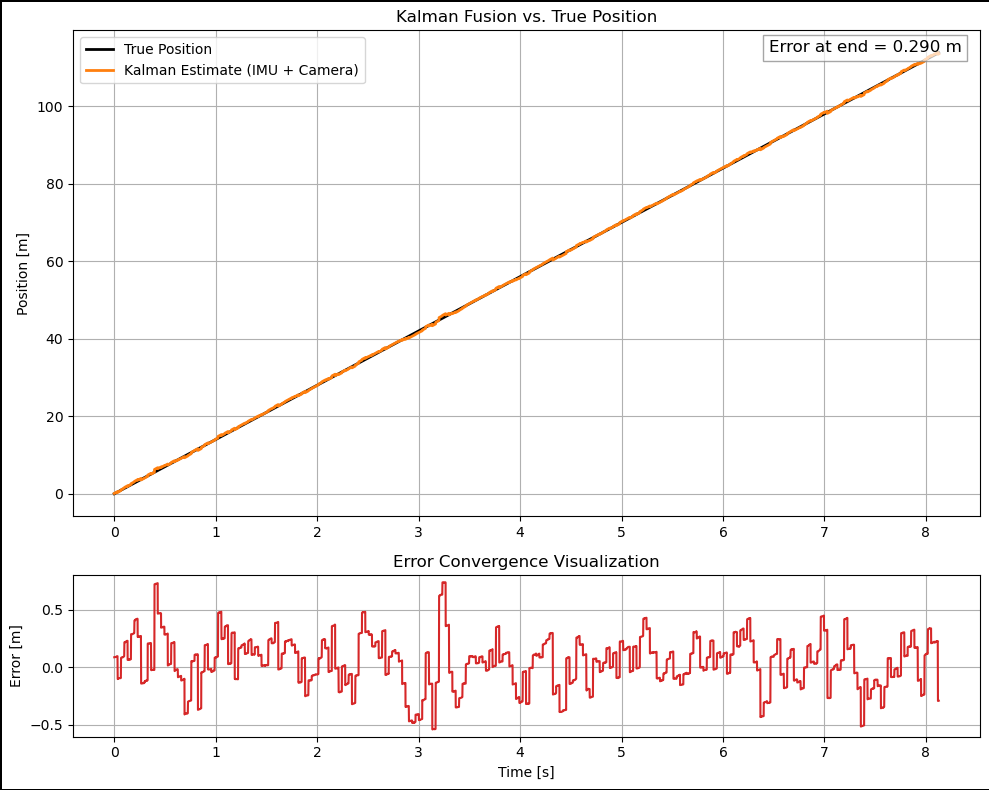

In [6]:
# Error Convergence für die Subplots berechnen 
err_imu_series    = imu_measured_positions    - true_positions
err_camera_series = camera_only_estimate      - true_positions
err_kalman_series = np.array(kalman_positions) - true_positions

# Plot 1: True Position und IMU only mit Error-Subplot und Rahmen
fig, (ax_main, ax_err) = plt.subplots(2, 1, figsize=(10, 8),
                                      gridspec_kw={'height_ratios': [3, 1]})
fig.patch.set_edgecolor('black')
fig.patch.set_linewidth(2)

# Hauptplot
ax_main.plot(t, true_positions, label='True Position', linewidth=2, color='black')
ax_main.plot(t, imu_measured_positions, label='IMU Only (Integrated)',
             alpha=0.8, linestyle='dotted', color='tab:blue')
ax_main.set_ylabel('Position [m]')
ax_main.set_title('IMU Only vs. True Position')
ax_main.legend()
ax_main.grid()
# End-Fehler anzeigen
ax_main.text(0.98, 0.98, f'Error at end = {err_imu:.3f} m',
             fontsize=12, ha='right', va='top', transform=ax_main.transAxes,
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='grey'))

# Error-Subplot
ax_err.plot(t, err_imu_series, label='Error', color='tab:red')
ax_err.set_ylabel('Error [m]')
ax_err.set_xlabel('Time [s]')
ax_err.set_title('Error Convergence Visualization')
ax_err.grid()
plt.tight_layout()
plt.show()

# Plot 2: True Position und Camera only mit Error-Subplot und Rahmen
fig, (ax_main, ax_err) = plt.subplots(2, 1, figsize=(10, 8),
                                      gridspec_kw={'height_ratios': [3, 1]})
fig.patch.set_edgecolor('black')
fig.patch.set_linewidth(2)

# Hauptplot
ax_main.plot(t, true_positions, label='True Position', linewidth=2, color='black')
ax_main.plot(t, camera_only_estimate, label='Camera Only (Interpolated)',
             alpha=0.8, linestyle='dashdot', color='tab:green')
ax_main.scatter(cam_indices * dt_imu, cam_measured_positions,
                color='red', label='Camera Measurements',
                zorder=5, alpha=0.3)  # Transparente Punkte
ax_main.set_ylabel('Position [m]')
ax_main.set_title('Camera Only vs. True Position')
ax_main.legend()
ax_main.grid()
# End-Fehler anzeigen
ax_main.text(0.98, 0.98, f'Error at end = {err_camera:.3f} m',
             fontsize=12, ha='right', va='top', transform=ax_main.transAxes,
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='grey'))

# Error-Subplot
ax_err.plot(t, err_camera_series, label='Error', color='tab:red')
ax_err.set_ylabel('Error [m]')
ax_err.set_xlabel('Time [s]')
ax_err.set_title('Error Convergence Visualization')
ax_err.grid()
plt.tight_layout()
plt.show()

# Plot 3: True Position und Kalman mit Error-Subplot und Rahmen
fig, (ax_main, ax_err) = plt.subplots(2, 1, figsize=(10, 8),
                                      gridspec_kw={'height_ratios': [3, 1]})
fig.patch.set_edgecolor('black')
fig.patch.set_linewidth(2)

# Hauptplot
ax_main.plot(t, true_positions, label='True Position', linewidth=2, color='black')
ax_main.plot(t, kalman_positions, label='Kalman Estimate (IMU + Camera)',
             linewidth=2, color='tab:orange')
ax_main.set_ylabel('Position [m]')
ax_main.set_title('Kalman Fusion vs. True Position')
ax_main.legend()
ax_main.grid()
# End-Fehler anzeigen
ax_main.text(0.98, 0.98, f'Error at end = {err_kalman:.3f} m',
             fontsize=12, ha='right', va='top', transform=ax_main.transAxes,
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='grey'))

# Error-Subplot
ax_err.plot(t, err_kalman_series, label='Error', color='tab:red')
ax_err.set_ylabel('Error [m]')
ax_err.set_xlabel('Time [s]')
ax_err.set_title('Error Convergence Visualization')
ax_err.grid()
plt.tight_layout()
plt.show()

## Conclusion

The performance of the Kalman filter is convincing. Despite the high drift of the IMU measurement data, the Kalman filter can use it sensibly to provide a high-quality estimate in combination with the camera data. 

To improve the model, it would be conceivable to set the parameters of the **Process Noise Covariance `Q`** using an algorithm instead of manually finding the optimum result. The aim would be to minimize the error convergence of the Kalman filter.